# IMPORT LIBRARY

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import warnings
import os
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)


# LOAD & PERSIAPAN DATA

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = '/content/drive/MyDrive/SKRIPSI/Data/ayam_harian.xlsx'
data = pd.read_excel(path)

In [6]:
series = (
    data
    .set_index("Tgl_Masuk")["harga_rata"]
    .asfreq("D")
)


## Imputasi Data Hilang

In [7]:
series.isna().sum()

np.int64(1)

In [8]:
series = series.interpolate(method="linear")
print("Missing value setelah imputasi :", series.isna().sum())

Missing value setelah imputasi : 0


## Grafik Pergerakan Harga Harian

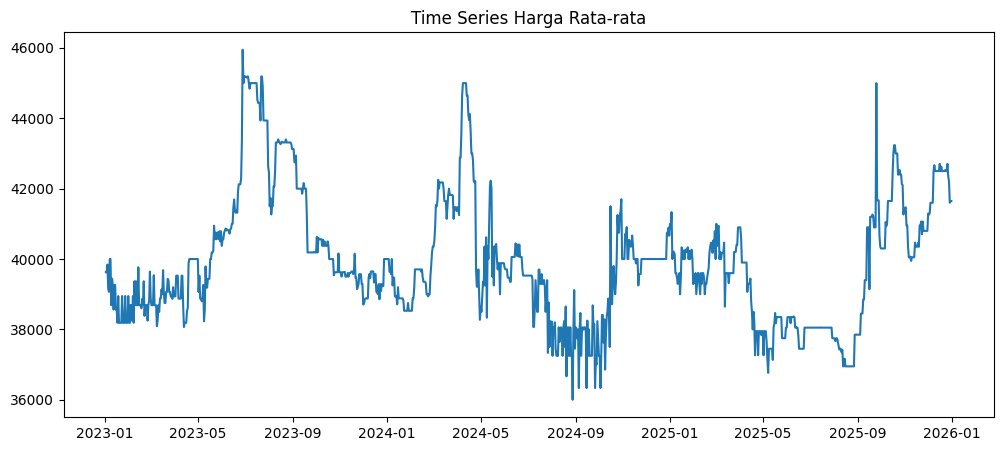

In [9]:
plt.figure(figsize=(12,5))
plt.plot(series)
plt.title("Time Series Harga Rata-rata")
plt.show()

In [10]:
# ===== FINAL SPLIT =====

train = series[:'2024-12-31']
test  = series['2025-01-01':]


print(f"\nTrain : {train.shape[0]} observasi ({train.index[0].date()} s.d. {train.index[-1].date()})")
print(f"Test  : {test.shape[0]}  observasi ({test.index[0].date()} s.d. {test.index[-1].date()})")


Train : 730 observasi (2023-01-02 s.d. 2024-12-31)
Test  : 365  observasi (2025-01-01 s.d. 2025-12-31)


# SIAPKAN FUNGSI DASAR

A. FUNGSI UTILITAS

In [11]:
def create_dataset(data, time_steps):
    """Ubah data 1D menjadi format supervised (X, y)"""
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps, 0])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)


def build_lstm_model(n_neurons, learning_rate, input_shape, n_layers=1):
    """Bangun arsitektur LSTM (1 atau 2 layer)"""
    model = Sequential()
    if n_layers == 1:
        model.add(LSTM(n_neurons, input_shape=input_shape))
    else:
        model.add(LSTM(n_neurons, return_sequences=True, input_shape=input_shape))
        model.add(LSTM(n_neurons))
    model.add(Dense(1))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse'
    )
    return model


def compute_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def compute_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

"""# CROSS VALIDATION

## EXPANDING WINDOW CV SPLITS UNTUK TUNING HYPERPARAMETER
"""

def get_cv_splits(train):
    splits = []
    splits.append((train['2023-01-01':'2023-06-30'],
                   train['2023-07-01':'2023-09-30']))   # Fold 1

    splits.append((train['2023-01-01':'2023-09-30'],
                   train['2023-10-01':'2023-12-31']))   # Fold 2

    splits.append((train['2023-01-01':'2023-12-31'],
                   train['2024-01-01':'2024-03-31']))   # Fold 3

    splits.append((train['2023-01-01':'2024-03-31'],
                   train['2024-04-01':'2024-06-30']))   # Fold 4

    splits.append((train['2023-01-01':'2024-06-30'],
                   train['2024-07-01':'2024-09-30']))   # Fold 5

    splits.append((train['2023-01-01':'2024-09-30'],
                   train['2024-10-01':'2024-12-31']))   # Fold 6

    return splits


# CROSS VALIDATION

## EXPANDING WINDOW CV SPLITS UNTUK TUNING HYPERPARAMETER

In [12]:

def get_cv_splits(train):
    splits = []
    splits.append((train['2023-01-01':'2023-06-30'],
                   train['2023-07-01':'2023-09-30']))   # Fold 1

    splits.append((train['2023-01-01':'2023-09-30'],
                   train['2023-10-01':'2023-12-31']))   # Fold 2

    splits.append((train['2023-01-01':'2023-12-31'],
                   train['2024-01-01':'2024-03-31']))   # Fold 3

    splits.append((train['2023-01-01':'2024-03-31'],
                   train['2024-04-01':'2024-06-30']))   # Fold 4

    splits.append((train['2023-01-01':'2024-06-30'],
                   train['2024-07-01':'2024-09-30']))   # Fold 5

    splits.append((train['2023-01-01':'2024-09-30'],
                   train['2024-10-01':'2024-12-31']))   # Fold 6

    return splits


# EVALUASI SATU KOMBINASI (untuk Skenario Tuning)

In [13]:
def evaluate_on_cv(train, time_steps, n_layers, n_neurons,
                   learning_rate, batch_size):
    """
    Latih & evaluasi satu kombinasi hyperparameter
    menggunakan Expanding Window CV di data latih (K=6).
    Return: rata-rata RMSE di semua fold.
    """

    splits = get_cv_splits(train)
    rmse_folds = []

    for train_fold, val_fold in splits:

        # =====================================================
        # Scaling (fit hanya pada train)
        # =====================================================
        scaler = MinMaxScaler()

        train_scaled = scaler.fit_transform(
            train_fold.values.reshape(-1, 1)
        )

        val_scaled = scaler.transform(
            val_fold.values.reshape(-1, 1)
        )

        # Tambahkan konteks dari train terakhir
        val_with_context = np.vstack([
            train_scaled[-time_steps:],
            val_scaled
        ])

        # =====================================================
        # Buat dataset supervised
        # =====================================================
        X_train, y_train = create_dataset(
            train_scaled,
            time_steps
        )

        X_val, y_val = create_dataset(
            val_with_context,
            time_steps
        )

        if len(X_train) == 0 or len(X_val) == 0:
            continue

        X_train = X_train.reshape(-1, time_steps, 1)
        X_val   = X_val.reshape(-1, time_steps, 1)

        # =====================================================
        # Bangun model
        # =====================================================

        tf.keras.backend.clear_session()
        model = build_lstm_model(
            n_neurons,
            learning_rate,
            (time_steps, 1),
            n_layers
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=1000,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0
        )

        # =====================================================
        # Prediksi
        # =====================================================
        pred = model.predict(X_val, verbose=0)

        pred_inv = scaler.inverse_transform(pred)
        y_inv = scaler.inverse_transform(
            y_val.reshape(-1, 1)
        )

        rmse_folds.append(
            compute_rmse(y_inv, pred_inv)
        )

    return np.mean(rmse_folds) if rmse_folds else np.inf

## SKENARIO 0 — Tuning Timestep, Layer, Batch Size

In [14]:

def skenario_0(train, fixed_neurons=16, fixed_lr=0.1):
    print("=" * 60)
    print("SKENARIO 0: Tuning Timestep, Layer, Batch Size")
    print("=" * 60)

    grid = [(ts, nl, bs)
            for ts in [7, 30]
            for nl in [1, 2]
            for bs in [32, 64, 128]]

    results = []
    for i, (ts, nl, bs) in enumerate(grid, 1):
        print(f"[{i}/{len(grid)}] Timestep={ts}, Layer={nl}, BatchSize={bs} ...", end=" ")
        avg_rmse = evaluate_on_cv(train, ts, nl, fixed_neurons, fixed_lr, bs)
        print(f"RMSE = {avg_rmse:.4f}")
        results.append({'Timestep': ts, 'N_Layers': nl,
                        'Batch_Size': bs, 'Avg_RMSE': avg_rmse})

    df = pd.DataFrame(results).sort_values('Avg_RMSE')
    print("\nHasil Skenario 0:\n", df.to_string(index=False))

    best    = df.iloc[0]
    best_ts = int(best['Timestep'])
    best_nl = int(best['N_Layers'])
    best_bs = int(best['Batch_Size'])
    print(f"\n✓ Terbaik → Timestep={best_ts}, Layer={best_nl}, BatchSize={best_bs}")
    return best_ts, best_nl, best_bs, df


## SKENARIO 1 — Tuning Neuron Hidden

In [15]:

def skenario_1(train, best_ts, best_nl, best_bs, fixed_lr=0.1):
    print("\n" + "=" * 60)
    print("SKENARIO 1: Tuning Neuron Hidden (10–25)")
    print("=" * 60)

    results = []
    for n in range(10, 26):
        print(f"Neuron={n} ...", end=" ")
        avg_rmse = evaluate_on_cv(train, best_ts, best_nl, n, fixed_lr, best_bs)
        print(f"RMSE = {avg_rmse:.4f}")
        results.append({'Neurons': n, 'Avg_RMSE': avg_rmse})

    df = pd.DataFrame(results).sort_values('Avg_RMSE')
    print("\nHasil Skenario 1:\n", df.to_string(index=False))

    best_neuron = int(df.iloc[0]['Neurons'])
    print(f"\n✓ Neuron terbaik: {best_neuron}")
    return best_neuron, df

## SKENARIO 2 — Tuning Learning Rate

In [16]:

def skenario_2(train, best_ts, best_nl, best_bs, best_neuron):
    print("\n" + "=" * 60)
    print("SKENARIO 2: Tuning Learning Rate")
    print("=" * 60)

    results = []
    for lr in [0.1, 0.01, 0.001, 0.0001, 0.00001]:
        print(f"LR={lr} ...", end=" ")
        avg_rmse = evaluate_on_cv(train, best_ts, best_nl,
                                  best_neuron, lr, best_bs)
        print(f"RMSE = {avg_rmse:.4f}")
        results.append({'Learning_Rate': lr, 'Avg_RMSE': avg_rmse})

    df = pd.DataFrame(results).sort_values('Avg_RMSE')
    print("\nHasil Skenario 2:\n", df.to_string(index=False))

    best_lr = df.iloc[0]['Learning_Rate']
    print(f"\n✓ LR terbaik: {best_lr}")
    return best_lr, df


## EXPANDING WINDOW SPLITS UNTUK EVALUASI KONSISTENSI MODEL

In [17]:
def get_eval_splits(series, n_val_days=90):
    """
    Digunakan untuk evaluasi konsistensi setelah hyperparameter terbaik
    ditemukan. Titik awal train selalu Jan 2023, jendela melebar
    1 bulan per fold ke arah data uji (2025).
    """
    val_starts = pd.date_range('2025-01-01', '2025-12-01', freq='MS')

    splits = []
    for val_start in val_starts:
        train_end = val_start - pd.Timedelta(days=1)
        val_end   = val_start + pd.Timedelta(days=n_val_days - 1)

        train_fold = series[:train_end.strftime('%Y-%m-%d')]
        val_fold   = series[val_start.strftime('%Y-%m-%d'):val_end.strftime('%Y-%m-%d')]

        splits.append((train_fold, val_fold))

    # Buang fold yang validasinya tidak cukup panjang untuk horizon terlama (90 hari)
    splits = [(tr, vl) for tr, vl in splits if len(vl) >= n_val_days]
    return splits

Drive mounted: True
Output dir   : /content/drive/MyDrive/SKRIPSI/Output
Dir exists   : True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

  PIPELINE LSTM: DAGING AYAM BROILER
SKENARIO 0: Tuning Timestep, Layer, Batch Size
[1/12] Timestep=7, Layer=1, BatchSize=32 ... 

RMSE = 489.6408
[2/12] Timestep=7, Layer=1, BatchSize=64 ... RMSE = 559.7082
[3/12] Timestep=7, Layer=1, BatchSize=128 ... RMSE = 465.6931
[4/12] Timestep=7, Layer=2, BatchSize=32 ... RMSE = 743.6542
[5/12] Timestep=7, Layer=2, BatchSize=64 ... RMSE = 638.0677
[6/12] Timestep=7, Layer=2, BatchSize=128 ... RMSE = 675.6735
[7/12] Timestep=30, Layer=1, BatchSize=32 ... RMSE = 471.5126
[8/12] Timestep=30, Layer=1, BatchSize=64 ... RMSE = 526.2317
[9/12] Timestep=30, Layer=1, BatchSize=128 ... RMSE = 476.9596
[10/12] Timestep=30, Layer=2, BatchSize=32 ... RMSE = 914.6991
[11/12] Timestep=30, Layer=2, BatchSize=64 ... RMSE = 752.4876
[12/12] Timestep=30, Layer=2, BatchSize=128 ... RMSE = 686.9789

Hasil Skenario 0:
  Timestep  N_Layers  Batch_Size   Avg_RMSE
        7         1         128 465.693101
       30         1          32 471.512630
       30         1         128 476.959553
        7         1          32 489.640775
       30         1          64 526.231652
        7         1   

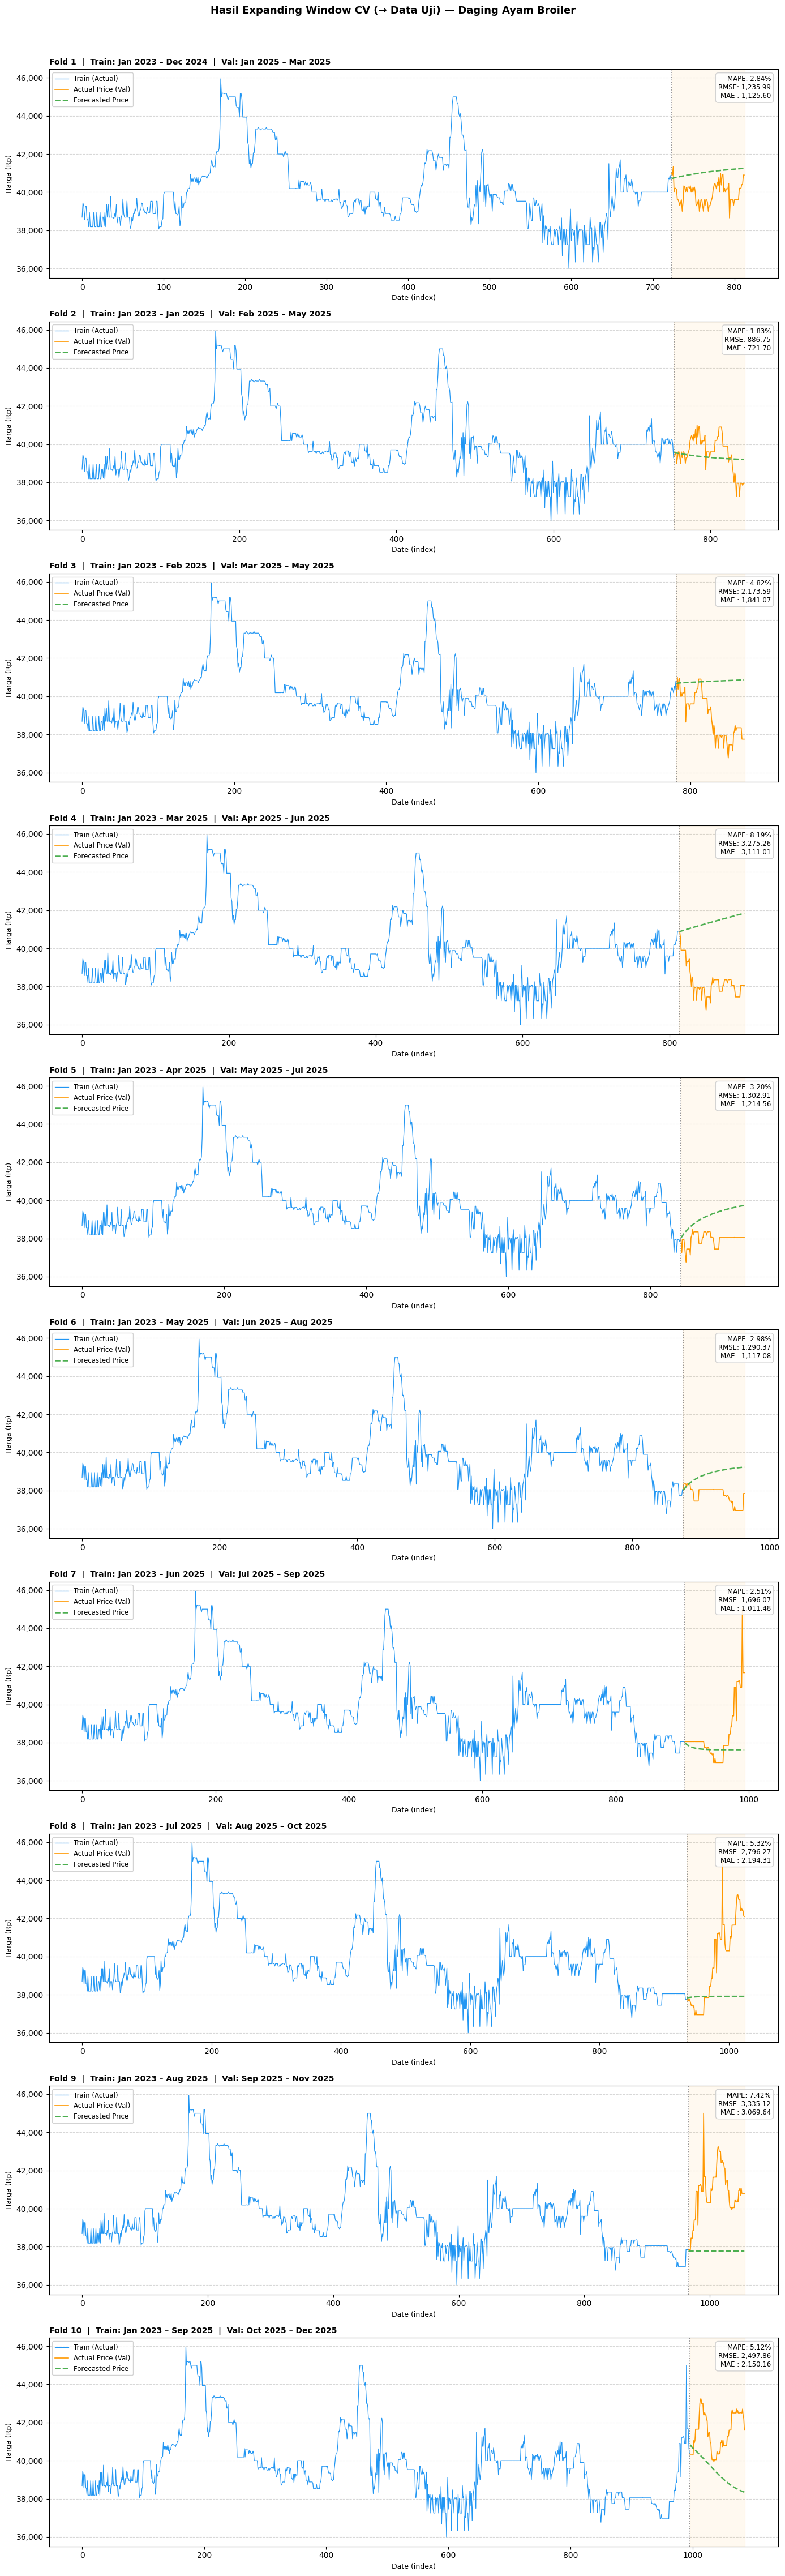

✓ Plot CV tersimpan: /content/drive/MyDrive/SKRIPSI/Output/plot_cv_daging_ayam_broiler.png


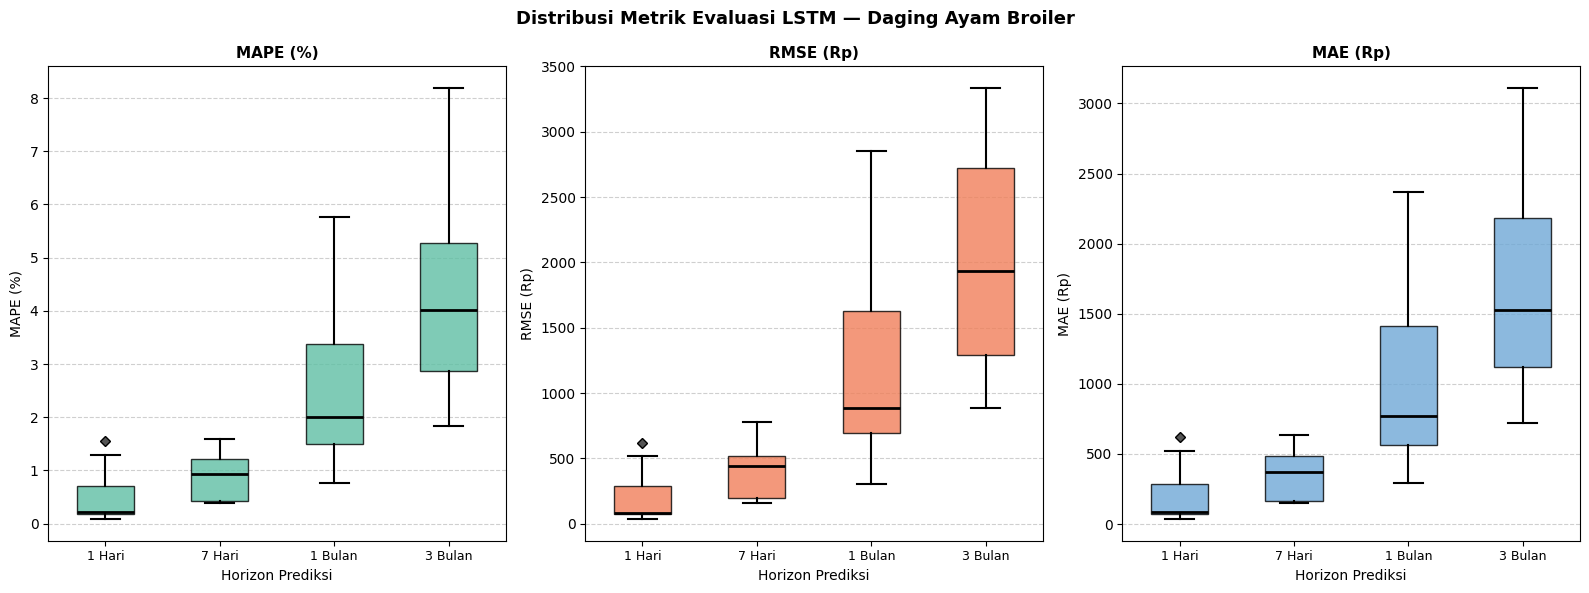

✓ Boxplot tersimpan: /content/drive/MyDrive/SKRIPSI/Output/boxplot_daging_ayam_broiler.png

✓ Semua hasil tersimpan → /content/drive/MyDrive/SKRIPSI/Output/hasil_expanding_window_cv_ayam.xlsx
  Fold 1 → MAPE=1.296%, RMSE=696.23, MAE=553.41
  Fold 2 → MAPE=0.418%, RMSE=230.89, MAE=165.60
  Fold 3 → MAPE=0.429%, RMSE=244.59, MAE=172.00
  Fold 4 → MAPE=0.967%, RMSE=640.66, MAE=391.32
  Fold 5 → MAPE=1.468%, RMSE=664.45, MAE=559.70
  Fold 6 → MAPE=0.836%, RMSE=581.47, MAE=329.98


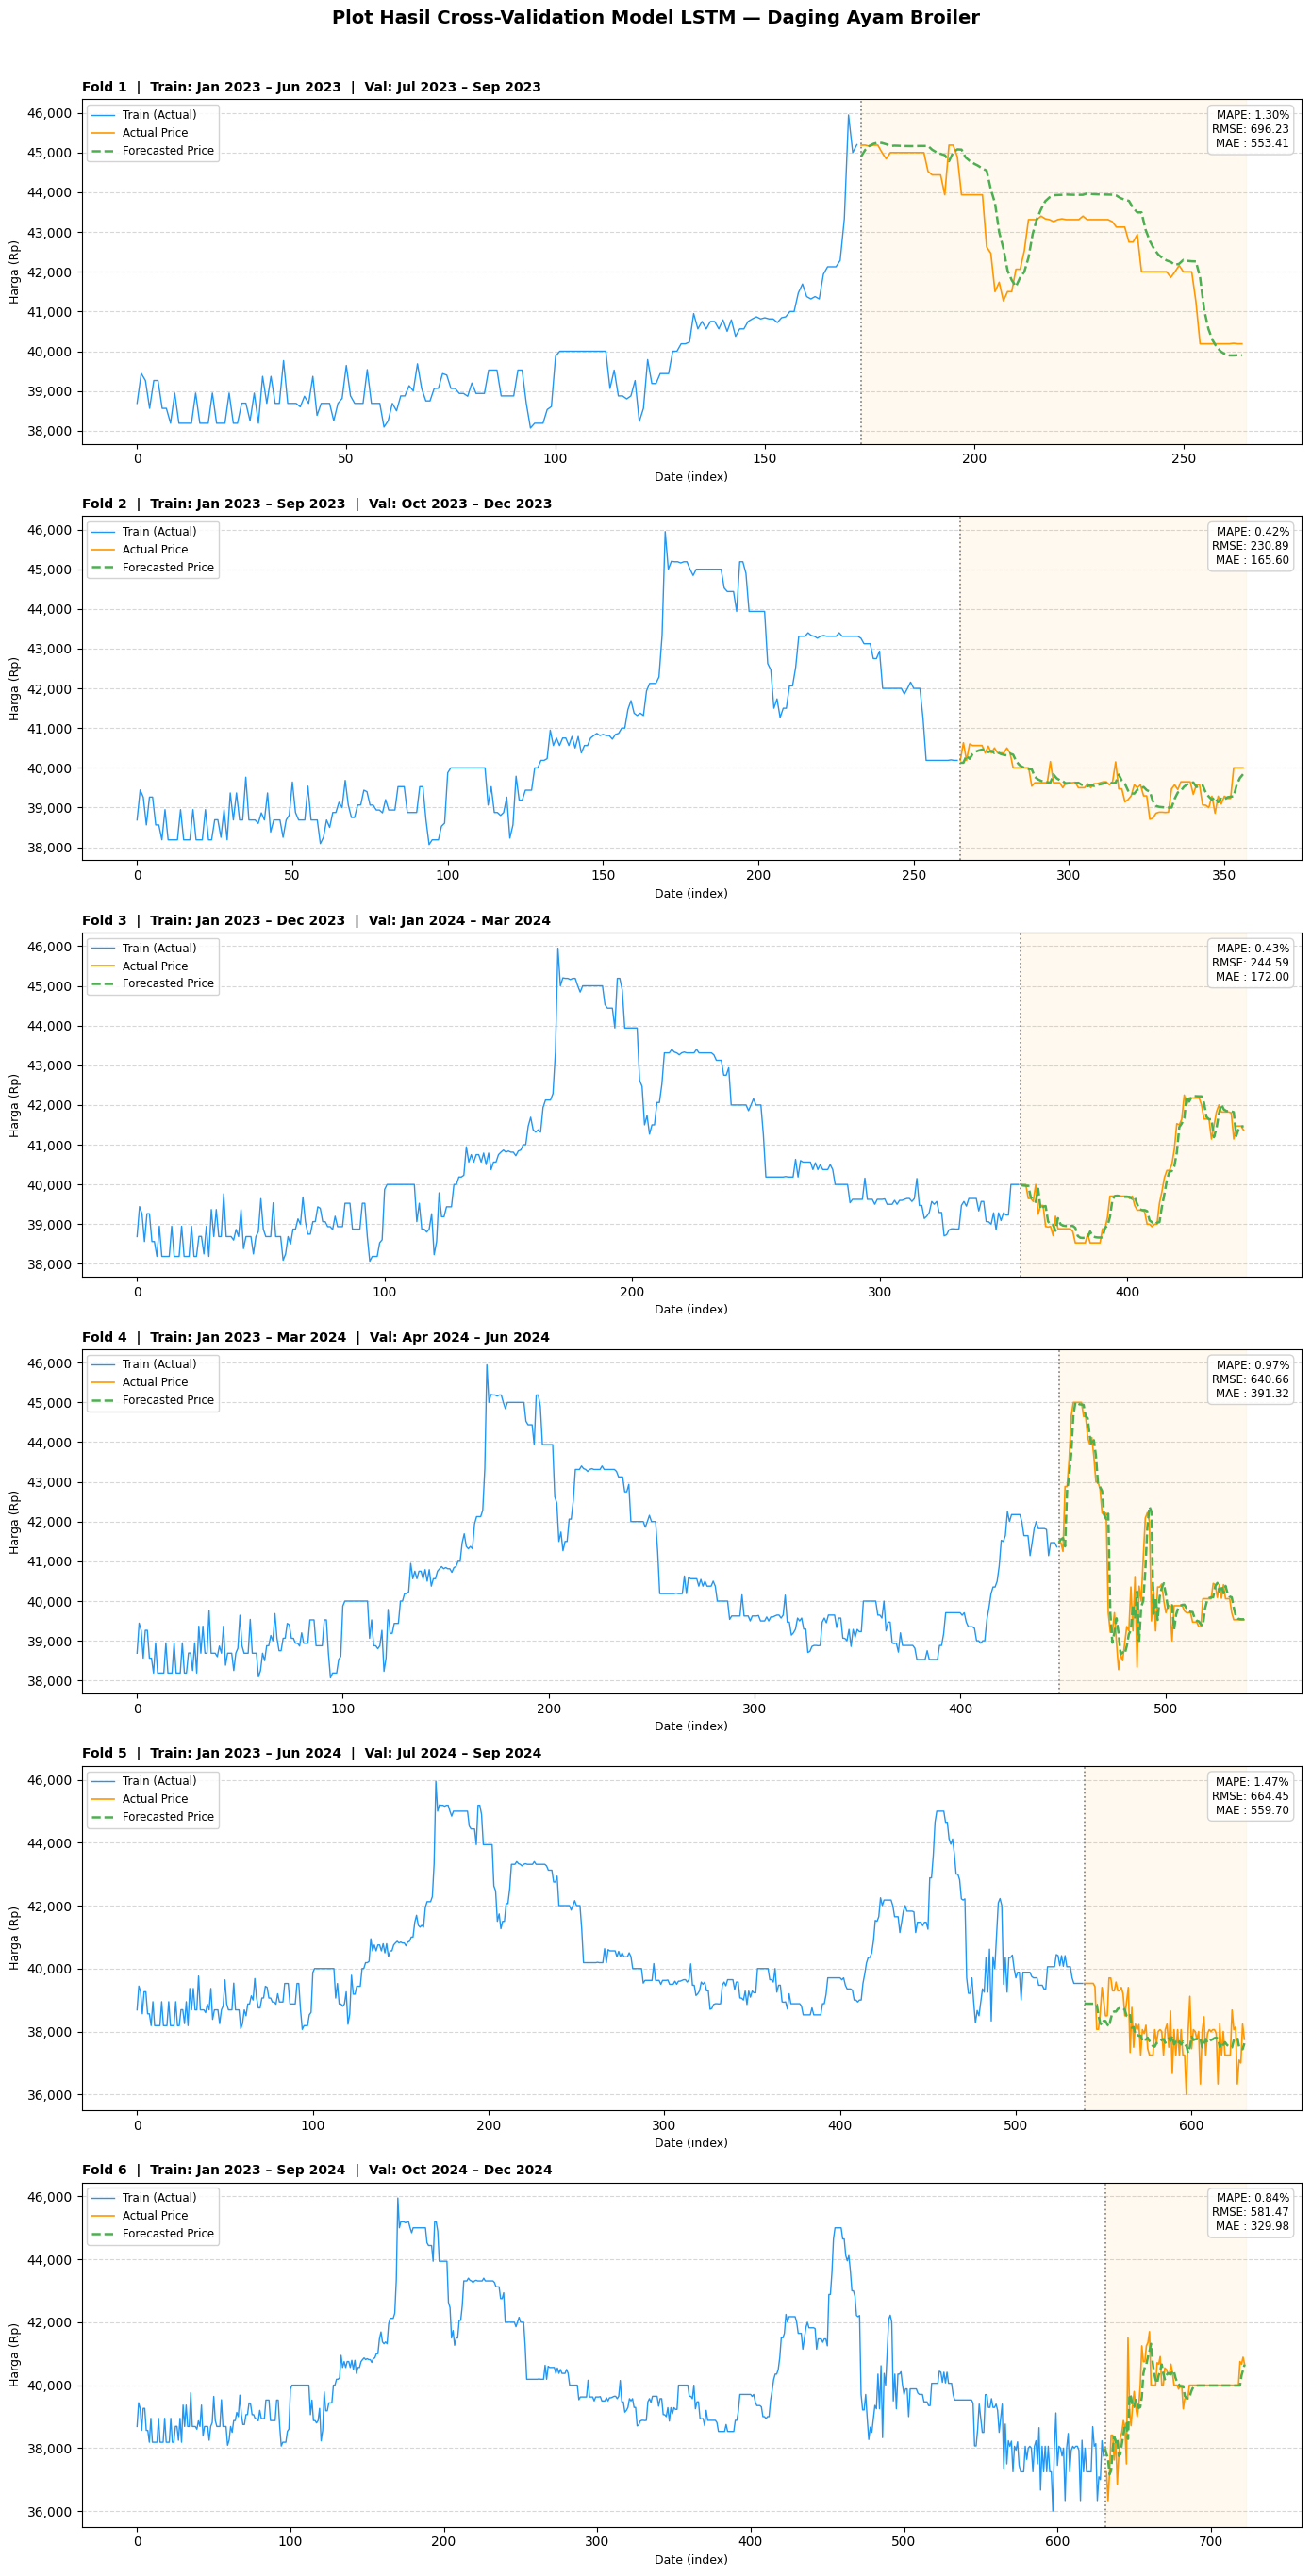


✓ Plot CV tersimpan: /content/drive/MyDrive/SKRIPSI/Output/Plot/plot_cv_daging_ayam_broiler.png
  ✓ Fold 1 tersimpan (90 baris, Val: 2025-01-01 s.d. 2025-03-31)
  ✓ Fold 2 tersimpan (90 baris, Val: 2025-02-01 s.d. 2025-05-01)
  ✓ Fold 3 tersimpan (90 baris, Val: 2025-03-01 s.d. 2025-05-29)
  ✓ Fold 4 tersimpan (90 baris, Val: 2025-04-01 s.d. 2025-06-29)
  ✓ Fold 5 tersimpan (90 baris, Val: 2025-05-01 s.d. 2025-07-29)
  ✓ Fold 6 tersimpan (90 baris, Val: 2025-06-01 s.d. 2025-08-29)
  ✓ Fold 7 tersimpan (90 baris, Val: 2025-07-01 s.d. 2025-09-28)
  ✓ Fold 8 tersimpan (90 baris, Val: 2025-08-01 s.d. 2025-10-29)
  ✓ Fold 9 tersimpan (90 baris, Val: 2025-09-01 s.d. 2025-11-29)
  ✓ Fold 10 tersimpan (90 baris, Val: 2025-10-01 s.d. 2025-12-29)
  ✓ Sheet gabungan 'Semua_Fold' tersimpan (900 total baris)

✓ File tersimpan → /content/drive/MyDrive/SKRIPSI/Output/aktual_prediksi_daging_ayam_broiler.xlsx
✓ Fold 1 tersimpan → /content/drive/MyDrive/SKRIPSI/Output/daging_ayam_broiler/fold_1.png
✓ F

['/content/drive/MyDrive/SKRIPSI/Output/daging_ayam_broiler/fold_1.png',
 '/content/drive/MyDrive/SKRIPSI/Output/daging_ayam_broiler/fold_2.png',
 '/content/drive/MyDrive/SKRIPSI/Output/daging_ayam_broiler/fold_3.png',
 '/content/drive/MyDrive/SKRIPSI/Output/daging_ayam_broiler/fold_4.png',
 '/content/drive/MyDrive/SKRIPSI/Output/daging_ayam_broiler/fold_5.png',
 '/content/drive/MyDrive/SKRIPSI/Output/daging_ayam_broiler/fold_6.png',
 '/content/drive/MyDrive/SKRIPSI/Output/daging_ayam_broiler/fold_7.png',
 '/content/drive/MyDrive/SKRIPSI/Output/daging_ayam_broiler/fold_8.png',
 '/content/drive/MyDrive/SKRIPSI/Output/daging_ayam_broiler/fold_9.png',
 '/content/drive/MyDrive/SKRIPSI/Output/daging_ayam_broiler/fold_10.png']

In [18]:
HORIZONS = {'1 Hari': 1, '7 Hari': 7, '1 Bulan': 30, '3 Bulan': 90}

def evaluasi_konsistensi(series, best_ts, best_nl, best_neuron,
                          best_lr, best_bs, komoditas="Komoditas",
                          n_internal_val=90):
    """
    Evaluasi konsistensi model LSTM — SETARA MEKANISME dengan
    Hybrid ARIMA-GARCH (evaluasi_konsistensi() versi R):

      1) Model di-fit SEKALI per fold, hanya memakai data latih
         (train_fold). Early stopping memakai validation split
         INTERNAL yang diambil dari ekor train_fold sendiri —
         BUKAN dari val_fold (periode uji 2025) — supaya tidak ada
         informasi dari periode yang sedang dievaluasi yang bocor
         ke proses training.
      2) Setelah model terlatih, dilakukan forecast 90 hari ke depan
         secara REKURSIF (multi-step): prediksi hari ke-t dipakai
         sebagai input untuk memprediksi hari ke-(t+1), dst — model
         TIDAK PERNAH melihat nilai aktual val_fold selama forecast.
         Ini menyamai ugarchforecast(..., n.ahead=90) pada ARIMA-GARCH.
      3) Forecast 90-hari itu lalu dipotong di 4 titik horizon
         (1, 7, 30, 90 hari) — horizon bersarang (nested), identik
         dengan skema ARIMA-GARCH.

    Catatan performa: forecast rekursif memanggil model.predict()
    satu langkah pada satu waktu (bukan batch), jadi akan lebih
    lambat dibanding versi one-shot lama — ini konsekuensi yang
    diperlukan supaya evaluasi bebas dari kebocoran data.
    """
    print("\n" + "=" * 65)
    print(f"EVALUASI KONSISTENSI (FORECAST REKURSIF) — {komoditas.upper()}")
    print(f"Expanding Window → Data Uji (2025)")
    print("=" * 65)

    splits  = get_eval_splits(series)
    metrics = {h: {'mape': [], 'rmse': [], 'mae': []} for h in HORIZONS}
    fold_results = []   # disimpan untuk plotting

    for fold_idx, (train_fold, val_fold) in enumerate(splits, 1):
        print(f"\n  Fold {fold_idx}/{len(splits)}")
        print(f"  Train : {train_fold.index[0].date()} s.d. "
              f"{train_fold.index[-1].date()} ({len(train_fold)} obs)")
        print(f"  Val   : {val_fold.index[0].date()} s.d. "
              f"{val_fold.index[-1].date()} ({len(val_fold)} obs)")

        n_forecast = len(val_fold)

        # =====================================================
        # Scaling (fit hanya pada train_fold — val_fold tidak disentuh)
        # =====================================================
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(
            train_fold.values.reshape(-1, 1)
        )

        if len(train_scaled) <= best_ts + 10:
            print("  → skip (data latih terlalu pendek)"); continue

        # =====================================================
        # Split INTERNAL untuk early stopping — murni dari ekor
        # train_fold, TIDAK memakai val_fold (periode uji)
        # =====================================================
        n_hold = min(n_internal_val, max(30, int(len(train_scaled) * 0.1)))
        train_inner   = train_scaled[:-n_hold]
        val_inner     = train_scaled[-n_hold:]
        val_inner_ctx = np.vstack([train_inner[-best_ts:], val_inner])

        X_train, y_train   = create_dataset(train_inner, best_ts)
        X_val_in, y_val_in = create_dataset(val_inner_ctx, best_ts)

        if len(X_train) == 0 or len(X_val_in) == 0:
            print("  → skip (dataset internal kosong)"); continue

        X_train  = X_train.reshape(-1, best_ts, 1)
        X_val_in = X_val_in.reshape(-1, best_ts, 1)

        # =====================================================
        # Bangun & latih model (hanya melihat data latih)
        # =====================================================
        tf.keras.backend.clear_session()
        model = build_lstm_model(
            best_neuron,
            best_lr,
            (best_ts, 1),
            best_nl
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val_in, y_val_in),
            epochs=1000,
            batch_size=best_bs,
            callbacks=[early_stop],
            verbose=0
        )

        n_epochs = len(history.history['loss'])

        # =====================================================
        # Forecast REKURSIF 90 hari ke depan (tanpa data val_fold)
        # =====================================================
        window = train_scaled[-best_ts:].reshape(1, best_ts, 1).copy()
        preds_scaled = []
        for _ in range(n_forecast):
            yhat = model.predict(window, verbose=0)[0, 0]
            preds_scaled.append(yhat)
            window = np.append(window[0, 1:, 0], yhat).reshape(1, best_ts, 1)

        pred_inv = scaler.inverse_transform(
            np.array(preds_scaled).reshape(-1, 1)
        ).flatten()
        y_inv = val_fold.values[:n_forecast]

        # Simpan untuk plotting
        pred_dates = val_fold.index[:n_forecast]

        fold_results.append({
            'fold'         : fold_idx,
            'train_fold'   : train_fold,
            'val_fold'     : val_fold,
            'train_actual' : train_fold.values,
            'y_actual'     : y_inv,
            'y_pred'       : pred_inv,
            'pred_dates'   : pred_dates,
            'epochs'       : n_epochs
        })

        # Hitung metrik per horizon
        print(f"\n  {'Horizon':<12} {'MAPE (%)':>10} {'RMSE':>12} {'MAE':>12}")
        print(f"  {'─'*48}")
        for h_name, h_len in HORIZONS.items():
            n = min(h_len, len(y_inv))
            if n > 0:
                yt, yp = y_inv[:n], pred_inv[:n]
                m = compute_mape(yt, yp)
                r = compute_rmse(yt, yp)
                a = compute_mae(yt, yp)
                metrics[h_name]['mape'].append(m)
                metrics[h_name]['rmse'].append(r)
                metrics[h_name]['mae'].append(a)
                print(f"  {h_name:<12} {m:>9.3f}% {r:>12.2f} {a:>12.2f}")

    # ── Tabel ringkasan rata-rata ────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  RINGKASAN RATA-RATA ANTAR FOLD — {komoditas.upper()}")
    print(f"  {'─'*60}")
    print(f"  {'Horizon':<12} {'MAPE (%)':>10} {'RMSE':>12} {'MAE':>12}")
    print(f"  {'─'*48}")

    summary_rows = []
    for h_name in HORIZONS:
        m        = metrics[h_name]
        avg_mape = np.mean(m['mape']) if m['mape'] else np.nan
        avg_rmse = np.mean(m['rmse']) if m['rmse'] else np.nan
        avg_mae  = np.mean(m['mae'])  if m['mae']  else np.nan
        print(f"  {h_name:<12} {avg_mape:>9.3f}% {avg_rmse:>12.2f} {avg_mae:>12.2f}")
        summary_rows.append({'Horizon'  : h_name,
                             'MAPE (%)' : round(avg_mape, 3),
                             'RMSE'     : round(avg_rmse, 2),
                             'MAE'      : round(avg_mae,  2)})
    print(f"{'='*65}")

    return pd.DataFrame(summary_rows), metrics, fold_results

"""# PLOT ACTUAL VS FORECAST PER FOLD"""

def plot_cv_folds(fold_results, best_ts, komoditas="Komoditas"):
    n_folds = len(fold_results)
    if n_folds == 0:
        print("Tidak ada fold untuk diplot."); return

    fig, axes = plt.subplots(n_folds, 1, figsize=(14, 4.5 * n_folds))
    if n_folds == 1:
        axes = [axes]

    fig.suptitle(f'Hasil Expanding Window CV (→ Data Uji) — {komoditas}',
                 fontsize=13, fontweight='bold', y=1.01)

    for res in fold_results:
        ax           = axes[res['fold'] - 1]
        train_actual = res['train_actual'][best_ts:]   # potong sesuai timestep
        y_inv        = res['y_actual']
        pred_inv     = res['y_pred']

        n_train_plot = len(train_actual)
        n_val_plot   = len(y_inv)
        x_train      = np.arange(n_train_plot)
        x_val        = np.arange(n_train_plot, n_train_plot + n_val_plot)

        mape_val = compute_mape(y_inv, pred_inv)
        rmse_val = compute_rmse(y_inv, pred_inv)
        mae_val  = compute_mae(y_inv,  pred_inv)

        # Plot
        ax.plot(x_train, train_actual,
                color='#2196F3', linewidth=0.9, label='Train (Actual)')
        ax.plot(x_val, y_inv,
                color='#FF9800', linewidth=1.2, label='Actual Price (Val)')
        ax.plot(x_val, pred_inv,
                color='#4CAF50', linewidth=1.8, label='Forecasted Price',
                linestyle='--')
        ax.axvline(x=n_train_plot, color='gray',
                   linestyle=':', linewidth=1.2)
        ax.axvspan(n_train_plot, n_train_plot + n_val_plot,
                   alpha=0.06, color='orange')

        train_fold = res['train_fold']
        val_fold   = res['val_fold']
        fold_label = (f"Fold {res['fold']}  |  "
                      f"Train: {train_fold.index[0].strftime('%b %Y')} – "
                      f"{train_fold.index[-1].strftime('%b %Y')}  |  "
                      f"Val: {val_fold.index[0].strftime('%b %Y')} – "
                      f"{val_fold.index[-1].strftime('%b %Y')}")
        ax.set_title(fold_label, fontsize=10, fontweight='bold', loc='left')

        metric_text = (f"MAPE: {mape_val:.2f}%\n"
                       f"RMSE: {rmse_val:,.2f}\n"
                       f"MAE : {mae_val:,.2f}")
        ax.text(0.99, 0.97, metric_text,
                transform=ax.transAxes, fontsize=8.5,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='#cccccc', alpha=0.85))

        ax.set_xlabel('Date (index)', fontsize=9)
        ax.set_ylabel('Harga (Rp)', fontsize=9)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        ax.legend(loc='upper left', fontsize=8.5, framealpha=0.85)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5)
        ax.set_axisbelow(True)

    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR,
                         f'plot_cv_{komoditas.lower().replace(" ","_")}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Plot CV tersimpan: {fname}")

"""# BOXPLOT DISTRIBUSI MAPE, RMSE, MAE"""

def plot_boxplots(metrics, komoditas="Komoditas"):
    horizon_labels = list(HORIZONS.keys())
    configs = [
        ('mape', 'MAPE (%)',  '#5fbfa4'),
        ('rmse', 'RMSE (Rp)', '#f07f5a'),
        ('mae',  'MAE (Rp)',  '#6fa8d6'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle(f'Distribusi Metrik Evaluasi LSTM — {komoditas}',
                 fontsize=13, fontweight='bold')

    for ax, (key, label, color) in zip(axes, configs):
        data_plot = [metrics[h][key] for h in horizon_labels]

        bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                        medianprops=dict(color='black', linewidth=2),
                        whiskerprops=dict(linewidth=1.5),
                        capprops=dict(linewidth=1.5),
                        flierprops=dict(marker='D', markersize=5,
                                        markerfacecolor='#555'))
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.8)

        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xticks(range(1, len(horizon_labels) + 1))
        ax.set_xticklabels(horizon_labels, fontsize=9)
        ax.set_xlabel('Horizon Prediksi', fontsize=10)
        ax.set_ylabel(label, fontsize=10)
        ax.yaxis.grid(True, linestyle='--', alpha=0.6)
        ax.set_axisbelow(True)

    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR,
                         f'boxplot_{komoditas.lower().replace(" ","_")}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Boxplot tersimpan: {fname}")

"""# SIMPAN SEMUA HASIL KE EXCEL"""

# ============================================================
# PERBAIKAN PATH — pastikan semua output ke Google Drive
# ============================================================

# Ganti OUTPUT_DIR ke path Google Drive yang benar
OUTPUT_DIR = '/content/drive/MyDrive/SKRIPSI/Output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verifikasi Drive sudah ter-mount
print("Drive mounted:", os.path.exists('/content/drive/MyDrive'))
print("Output dir   :", OUTPUT_DIR)
print("Dir exists   :", os.path.exists(OUTPUT_DIR))

def simpan_semua_hasil(list_hasil, output_dir=OUTPUT_DIR):

    output_path = os.path.join(
        output_dir,
        'hasil_expanding_window_cv_ayam.xlsx'
    )

    all_detail    = []
    all_ringkasan = []
    all_hp        = []

    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

        for hasil_dict in list_hasil:

            komoditas    = hasil_dict['komoditas']
            metrics      = hasil_dict['metrics']
            summary      = hasil_dict['summary']
            fold_results = hasil_dict['fold_results']

            # ======================================================
            # DETAIL FOLD
            # ======================================================
            for h_name in HORIZONS:

                m = metrics[h_name]

                for fold_idx in range(len(m['mape'])):

                    all_detail.append({
                        'Komoditas': komoditas,
                        'Horizon'  : h_name,
                        'Fold'     : fold_idx + 1,
                        'MAPE (%)' : round(m['mape'][fold_idx], 4),
                        'RMSE'     : round(m['rmse'][fold_idx], 2),
                        'MAE'      : round(m['mae'][fold_idx], 2)
                    })

            # ======================================================
            # RINGKASAN
            # ======================================================
            for _, row in summary.iterrows():

                all_ringkasan.append({
                    'Komoditas': komoditas,
                    'Horizon'  : row['Horizon'],
                    'MAPE (%)' : row['MAPE (%)'],
                    'RMSE'     : row['RMSE'],
                    'MAE'      : row['MAE']
                })

            # ======================================================
            # HYPERPARAMETER
            # ======================================================
            all_hp.append({
                'Komoditas'    : komoditas,
                'Timestep'     : hasil_dict['timestep'],
                'N_Layer'      : hasil_dict['layer'],
                'Batch_Size'   : hasil_dict['batch_size'],
                'Neuron'       : hasil_dict['neuron'],
                'Learning_Rate': hasil_dict['lr'],
                'Max_Epoch'    : 1000,
                'EarlyStopping': 'patience=10, monitor=val_loss'
            })

            # ======================================================
            # SHEET PREDIKSI PER FOLD
            # ======================================================
            for res in fold_results:

                fold_idx = res['fold']
                val_fold = res['val_fold']

                y_actual = res['y_actual']
                y_pred   = res['y_pred']

                val_dates = val_fold.index[
                    len(val_fold) - len(y_actual):
                ]

                error = y_actual - y_pred

                pct_error = np.where(
                    y_actual != 0,
                    np.abs(error / y_actual) * 100,
                    np.nan
                )

                df_pred = pd.DataFrame({
                    'Tanggal'       : val_dates,
                    'Aktual'        : np.round(y_actual, 2),
                    'Prediksi'      : np.round(y_pred, 2),
                    'Error'         : np.round(error, 2),
                    'Abs_Error (%)' : np.round(pct_error, 4)
                })

                # Horizon bersifat KUMULATIF/BERSARANG (nested): hari ke-i
                # termasuk dalam evaluasi horizon manapun yang h_len > i,
                # persis seperti cara metrik dihitung di atas (yt = y_actual[:n]).
                # Jadi hari ke-1 termasuk dalam SEMUA horizon (1/7/30/90 hari),
                # bukan cuma horizon "1 Hari" saja.
                horizon_label = [
                    ", ".join(h for h, h_len in HORIZONS.items() if i < h_len)
                    for i in range(len(df_pred))
                ]

                df_pred.insert(
                    1,
                    'Termasuk_dalam_Horizon',
                    horizon_label
                )

                # ==================================================
                # METRIK DI BAGIAN BAWAH
                # ==================================================
                summary_pred_rows = []

                for h_name, h_len in HORIZONS.items():

                    n = min(h_len, len(y_actual))

                    if n > 0:

                        yt = y_actual[:n]
                        yp = y_pred[:n]

                        summary_pred_rows.append({
                            'Tanggal'               : f'[METRIK {h_name}]',
                            'Termasuk_dalam_Horizon': h_name,
                            'Aktual'                : '',
                            'Prediksi'     : '',
                            'Error':
                                f"MAPE={compute_mape(yt, yp):.3f}%",
                            'Abs_Error (%)':
                                f"RMSE={compute_rmse(yt, yp):.2f} | "
                                f"MAE={compute_mae(yt, yp):.2f}"
                        })

                df_summary_pred = pd.DataFrame(
                    summary_pred_rows
                )

                df_kosong = pd.DataFrame([
                    {col: '' for col in df_pred.columns}
                ])

                df_fold_final = pd.concat(
                    [
                        df_pred,
                        df_kosong,
                        df_summary_pred
                    ],
                    ignore_index=True
                )

                # Nama sheet unik
                nama_komoditas = (
                    komoditas
                    .replace(" ", "_")
                    .replace("/", "_")
                )

                sheet_name = (
                    f"{nama_komoditas[:15]}_F{fold_idx}"
                )

                df_fold_final.to_excel(
                    writer,
                    sheet_name=sheet_name,
                    index=False
                )

        # ==========================================================
        # SHEET UTAMA
        # ==========================================================
        pd.DataFrame(all_detail).to_excel(
            writer,
            sheet_name='Detail_Fold',
            index=False
        )

        pd.DataFrame(all_ringkasan).to_excel(
            writer,
            sheet_name='Ringkasan',
            index=False
        )

        pd.DataFrame(all_hp).to_excel(
            writer,
            sheet_name='Hyperparameter',
            index=False
        )

    print(f"\n✓ Semua hasil tersimpan → {output_path}")

    return output_path

def run_pipeline(series, komoditas="Komoditas"):
    """
    Pipeline lengkap:
    1. Tuning hyperparameter (expanding CV di dalam data latih)
    2. Evaluasi konsistensi (expanding CV melebar ke data uji)
    3. Plot per fold & boxplot
    """
    # Pisahkan data latih dari series
    train = series[:'2024-12-31']

    print(f"\n{'='*65}")
    print(f"  PIPELINE LSTM: {komoditas.upper()}")
    print(f"{'='*65}")

    # ── Tahap 1: Tuning hyperparameter (hanya di data latih) ────────
    best_ts, best_nl, best_bs, df0 = skenario_0(train)
    best_neuron, df1               = skenario_1(train, best_ts, best_nl, best_bs)
    best_lr, df2                   = skenario_2(train, best_ts, best_nl,
                                                best_bs, best_neuron)

    print(f"\n{'='*65}")
    print(f"HYPERPARAMETER TERBAIK — {komoditas.upper()}")
    print(f"  Timestep      : {best_ts}")
    print(f"  Layer         : {best_nl}")
    print(f"  Batch Size    : {best_bs}")
    print(f"  Neuron        : {best_neuron}")
    print(f"  Learning Rate : {best_lr}")
    print(f"  Epoch         : EarlyStopping (maks 1000, patience=10)")
    print(f"{'='*65}")

    # ── Tahap 2: Evaluasi konsistensi (expanding ke data uji) ───────
    df_summary, metrics, fold_results = evaluasi_konsistensi(
        series, best_ts, best_nl, best_neuron, best_lr, best_bs, komoditas
    )

    # ── Tahap 3: Visualisasi ────────────────────────────────────────────────
    plot_cv_folds(fold_results, best_ts, komoditas)
    plot_boxplots(metrics, komoditas)

    return {
        'komoditas' : komoditas,
        'timestep'  : best_ts,  'layer'      : best_nl,
        'batch_size': best_bs,  'neuron'     : best_neuron,
        'lr'        : best_lr,  'summary'    : df_summary,
        'metrics'   : metrics,  'fold_results': fold_results,
    }

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
from google.colab import drive
drive.mount('/content/drive')


OUTPUT_DIR = '/content/drive/MyDrive/SKRIPSI/Output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

hasil_ayam = run_pipeline(series, komoditas="Daging Ayam Broiler")

# Simpan hasil ke Excel
simpan_semua_hasil([hasil_ayam])

def plot_cv_folds_tuning(train, best_ts, best_nl, best_neuron, best_lr, best_bs,
                         komoditas="Komoditas",
                         output_dir='/content/drive/MyDrive/SKRIPSI/Output/Plot'):
    """
    NAMA DIUBAH dari plot_cv_folds() -> plot_cv_folds_tuning() supaya
    tidak lagi menimpa plot_cv_folds() di atas (yang mem-plot fold
    EVALUASI KONSISTENSI 2025). Fungsi ini mem-plot fold TUNING
    hyperparameter (2023-2024), tujuannya beda, jadi harus beda nama.
    """
    os.makedirs(output_dir, exist_ok=True)
    splits = get_cv_splits(train)

    n_folds = len(splits)
    fig, axes = plt.subplots(n_folds, 1, figsize=(14, 4.5 * n_folds))
    fig.suptitle(f'Plot Hasil Cross-Validation Model LSTM — {komoditas}',
                 fontsize=14, fontweight='bold', y=1.01)

    for fold_idx, (train_fold, val_fold) in enumerate(splits):
        ax = axes[fold_idx]

        # ── Fit scaler & scale ───────────────────────────────────────
        combined        = pd.concat([train_fold, val_fold])
        scaler          = MinMaxScaler()
        combined_scaled = scaler.fit_transform(combined.values.reshape(-1, 1))

        n_train          = len(train_fold)
        train_scaled     = combined_scaled[:n_train]
        val_with_context = combined_scaled[n_train - best_ts:]

        X_train, y_train = create_dataset(train_scaled, best_ts)
        X_val,   y_val   = create_dataset(val_with_context, best_ts)

        if len(X_train) == 0 or len(X_val) == 0:
            ax.set_visible(False)
            continue

        X_train = X_train.reshape(-1, best_ts, 1)
        X_val   = X_val.reshape(-1, best_ts, 1)

        # ── Latih model ──────────────────────────────────────────────
        model = build_lstm_model(best_neuron, best_lr, (best_ts, 1), best_nl)
        early_stop = EarlyStopping(monitor='val_loss', patience=10,
                                   restore_best_weights=True)
        model.fit(X_train, y_train,
                  validation_data=(X_val, y_val),
                  epochs=1000, batch_size=best_bs,
                  callbacks=[early_stop], verbose=0)

        # ── Prediksi & inverse transform ─────────────────────────────
        pred     = model.predict(X_val, verbose=0)
        pred_inv = scaler.inverse_transform(pred).flatten()
        y_inv    = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()

        # ── Hitung metrik fold ini ───────────────────────────────────
        mape_val = compute_mape(y_inv, pred_inv)
        rmse_val = compute_rmse(y_inv, pred_inv)
        mae_val  = compute_mae(y_inv,  pred_inv)

        # ── Index untuk sumbu x ──────────────────────────────────────
        # Bagian train (hanya actual, tanpa prediksi)
        train_actual_inv = scaler.inverse_transform(train_scaled).flatten()
        # Potong sesuai panjang setelah create_dataset (time_steps pertama terpotong)
        train_plot_inv = train_actual_inv[best_ts:]

        n_train_plot = len(train_plot_inv)
        n_val_plot   = len(y_inv)

        x_train = np.arange(n_train_plot)
        x_val   = np.arange(n_train_plot, n_train_plot + n_val_plot)

        # ── Plot ─────────────────────────────────────────────────────
        # Train: garis biru (actual saja)
        ax.plot(x_train, train_plot_inv,
                color='#2196F3', linewidth=1.0, label='Train (Actual)')

        # Validasi: actual (oranye) vs forecast (hijau)
        ax.plot(x_val, y_inv,
                color='#FF9800', linewidth=1.2, label='Actual Price')
        ax.plot(x_val, pred_inv,
                color='#4CAF50', linewidth=1.8, label='Forecasted Price',
                linestyle='--')

        # Garis pemisah train | validasi
        ax.axvline(x=n_train_plot, color='gray', linestyle=':', linewidth=1.2)

        # Shading area validasi
        ax.axvspan(n_train_plot, n_train_plot + n_val_plot,
                   alpha=0.06, color='orange')

        # Label periode fold
        fold_label = (f"Fold {fold_idx + 1}  |  "
                      f"Train: {train_fold.index[0].strftime('%b %Y')} – "
                      f"{train_fold.index[-1].strftime('%b %Y')}  |  "
                      f"Val: {val_fold.index[0].strftime('%b %Y')} – "
                      f"{val_fold.index[-1].strftime('%b %Y')}")
        ax.set_title(fold_label, fontsize=10, fontweight='bold', loc='left')

        # Anotasi metrik di pojok kanan atas
        metric_text = (f"MAPE: {mape_val:.2f}%\n"
                       f"RMSE: {rmse_val:,.2f}\n"
                       f"MAE : {mae_val:,.2f}")
        ax.text(0.99, 0.97, metric_text,
                transform=ax.transAxes, fontsize=8.5,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='#cccccc', alpha=0.85))

        ax.set_xlabel('Date (index)', fontsize=9)
        ax.set_ylabel('Harga (Rp)', fontsize=9)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        ax.legend(loc='upper left', fontsize=8.5, framealpha=0.85)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5)
        ax.set_axisbelow(True)

        print(f"  Fold {fold_idx + 1} → MAPE={mape_val:.3f}%, "
              f"RMSE={rmse_val:.2f}, MAE={mae_val:.2f}")

    plt.tight_layout()
    fname = os.path.join(output_dir,
                         f'plot_cv_{komoditas.lower().replace(" ", "_")}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Plot CV tersimpan: {fname}")


# ============================================================
# 15. PENGGUNAAN
# ============================================================

# Setelah run_pipeline() selesai dan hyperparameter sudah ditemukan:

plot_cv_folds_tuning(
    train       = train,
    best_ts     = hasil_ayam['timestep'],
    best_nl     = hasil_ayam['layer'],
    best_neuron = hasil_ayam['neuron'],
    best_lr     = hasil_ayam['lr'],
    best_bs     = hasil_ayam['batch_size'],
    komoditas   = "Daging Ayam Broiler"
)

# ============================================================
# TAMBAHAN: Simpan Data Aktual vs Prediksi per Fold
# (Letakkan setelah fungsi evaluasi_konsistensi di pipeline)
# ============================================================

def simpan_aktual_prediksi(fold_results, komoditas="Komoditas",
                            output_dir=OUTPUT_DIR):
    """
    Menyimpan data aktual vs prediksi dari setiap fold
    evaluasi konsistensi ke dalam satu file Excel,
    masing-masing fold di sheet terpisah.

    Parameters:
    - fold_results : list hasil dari evaluasi_konsistensi()
    - komoditas    : nama komoditas (untuk nama file)
    - output_dir   : folder output di Google Drive
    """
    if not fold_results:
        print("Tidak ada data fold untuk disimpan.")
        return

    fname = os.path.join(
        output_dir,
        f'aktual_prediksi_{komoditas.lower().replace(" ", "_")}.xlsx'
    )

    with pd.ExcelWriter(fname, engine='openpyxl') as writer:
        for res in fold_results:
            fold_idx   = res['fold']
            val_fold   = res['val_fold']
            y_actual   = res['y_actual']
            y_pred     = res['y_pred']

            # Sesuaikan panjang index tanggal dengan panjang prediksi
            # (ada potongan timestep di awal val_with_context)
            n          = len(y_actual)
            val_index  = val_fold.index[:n]

            # Hitung metrik per baris horizon untuk referensi
            mape = compute_mape(y_actual, y_pred)
            rmse = compute_rmse(y_actual, y_pred)
            mae  = compute_mae(y_actual,  y_pred)

            df_fold = pd.DataFrame({
                'Tanggal'      : val_index,
                'Aktual (Rp)'  : y_actual,
                'Prediksi (Rp)': y_pred,
                'Error (Rp)'   : y_actual - y_pred,
                'APE (%)'      : (np.abs(y_actual - y_pred)
                                  / np.where(y_actual != 0, y_actual, np.nan)) * 100,
            })

            # Tambah baris ringkasan metrik di bawah
            ringkasan = pd.DataFrame([
                {'Tanggal': 'MAPE (%)', 'Aktual (Rp)': round(mape, 4)},
                {'Tanggal': 'RMSE'    , 'Aktual (Rp)': round(rmse, 2)},
                {'Tanggal': 'MAE'     , 'Aktual (Rp)': round(mae,  2)},
            ])

            sheet_name = f'Fold_{fold_idx}'
            df_fold.to_excel(writer, sheet_name=sheet_name, index=False)

            # Tulis ringkasan metrik di bawah tabel utama
            start_row = len(df_fold) + 3   # 2 baris jarak
            ringkasan.to_excel(writer, sheet_name=sheet_name,
                               index=False, header=False,
                               startrow=start_row)

            # Tulis label "Ringkasan Metrik" di atas tabel ringkasan
            ws = writer.sheets[sheet_name]
            ws.cell(row=start_row, column=1, value='Ringkasan Metrik')
            ws.cell(row=start_row + 1, column=1, value='MAPE (%)')
            ws.cell(row=start_row + 1, column=2, value=round(mape, 4))
            ws.cell(row=start_row + 2, column=1, value='RMSE')
            ws.cell(row=start_row + 2, column=2, value=round(rmse, 2))
            ws.cell(row=start_row + 3, column=1, value='MAE')
            ws.cell(row=start_row + 3, column=2, value=round(mae,  2))

            print(f"  ✓ Fold {fold_idx} tersimpan "
                  f"({len(df_fold)} baris, "
                  f"Val: {val_fold.index[0].date()} s.d. {val_fold.index[n-1].date()})")

        # Sheet terakhir: gabungan semua fold
        all_rows = []
        for res in fold_results:
            fold_idx  = res['fold']
            val_fold  = res['val_fold']
            y_actual  = res['y_actual']
            y_pred    = res['y_pred']
            n         = len(y_actual)
            val_index = val_fold.index[:n]

            df_temp = pd.DataFrame({
                'Fold'         : fold_idx,
                'Tanggal'      : val_index,
                'Aktual (Rp)'  : y_actual,
                'Prediksi (Rp)': y_pred,
                'Error (Rp)'   : y_actual - y_pred,
                'APE (%)'      : (np.abs(y_actual - y_pred)
                                  / np.where(y_actual != 0, y_actual, np.nan)) * 100,
            })
            all_rows.append(df_temp)

        df_all = pd.concat(all_rows, ignore_index=True)
        df_all.to_excel(writer, sheet_name='Semua_Fold', index=False)
        print(f"  ✓ Sheet gabungan 'Semua_Fold' tersimpan "
              f"({len(df_all)} total baris)")

    print(f"\n✓ File tersimpan → {fname}")
    return fname


# ============================================================
# INTEGRASI KE PIPELINE
# Tambahkan baris ini di dalam run_pipeline(), setelah
# evaluasi_konsistensi() dipanggil:
#
#   df_summary, metrics, fold_results = evaluasi_konsistensi(...)
#   simpan_aktual_prediksi(fold_results, komoditas)   # ← tambahkan ini
#
# ATAU panggil langsung setelah run_pipeline() selesai:
# ============================================================

# Panggil langsung (jika run_pipeline sudah dijalankan):
simpan_aktual_prediksi(
    fold_results = hasil_ayam['fold_results'],
    komoditas    = "Daging Ayam Broiler"
)

import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

def plot_cv_folds_per_fold(
    fold_results,
    komoditas="Komoditas",
    output_dir=OUTPUT_DIR
):

    folder_komoditas = os.path.join(
        output_dir,
        komoditas.lower().replace(" ", "_")
    )
    os.makedirs(folder_komoditas, exist_ok=True)

    file_paths = []

    for res in fold_results:

        fig, ax = plt.subplots(figsize=(11, 4))

        fold_idx   = res['fold']
        train_fold = res['train_fold']
        val_fold   = res['val_fold']
        y_actual   = np.asarray(res['y_actual'])
        y_pred     = np.asarray(res['y_pred'])

        n = len(y_actual)
        val_index = val_fold.index[:n]

        full_index = train_fold.index.append(val_index)
        x_pos = np.arange(len(full_index))
        train_n = len(train_fold)

        # TRAIN
        ax.plot(
            x_pos[:train_n],
            train_fold.values,
            color='#3B7DD8',
            linewidth=0.9,
            label='Train (Aktual)'
        )

        # AKTUAL VALIDASI
        ax.plot(
            x_pos[train_n:train_n+n],
            y_actual,
            color='#2E9E4D',
            linewidth=1.1,
            label='Actual Price (Val)'
        )

        # PREDIKSI
        ax.plot(
            x_pos[train_n:train_n+n],
            y_pred,
            color='#E0902A',
            linestyle='--',
            marker='o',
            markersize=2,
            linewidth=1.1,
            label='Forecasted Price'
        )

        # Area validasi
        ax.axvspan(
            x_pos[train_n],
            x_pos[train_n+n-1],
            color='#F5A623',
            alpha=0.12
        )

        # Metrik
        mape = compute_mape(y_actual, y_pred)
        rmse = compute_rmse(y_actual, y_pred)
        mae  = compute_mae(y_actual, y_pred)

        ax.text(
            0.99, 0.96,
            f"MAPE: {mape:.2f}%\nRMSE: {rmse:.2f}\nMAE: {mae:.2f}",
            transform=ax.transAxes,
            fontsize=8,
            ha='right',
            va='top',
            bbox=dict(
                boxstyle='round',
                facecolor='white',
                alpha=0.85
            )
        )

        train_start = train_fold.index[0].strftime('%b %Y')
        train_end   = train_fold.index[-1].strftime('%b %Y')
        val_start   = val_index[0].strftime('%b %Y')
        val_end     = val_index[-1].strftime('%b %Y')

        ax.set_title(
            f"Fold {fold_idx} | Train: {train_start}-{train_end} | "
            f"Val: {val_start}-{val_end}",
            fontsize=10,
            fontweight='bold'
        )

        ax.set_ylabel("Harga (Rp)")
        ax.set_xlabel("Date Index (Hari)")
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, _: f"{v:,.0f}")
        )

        ax.grid(True, linestyle=':')
        ax.legend()

        plt.tight_layout()

        # Simpan per fold
        fname = os.path.join(
            folder_komoditas,
            f"fold_{fold_idx}.png"
        )

        plt.savefig(fname, dpi=300, bbox_inches='tight')
        plt.close()

        file_paths.append(fname)

        print(f"✓ Fold {fold_idx} tersimpan → {fname}")

    return file_paths

plot_cv_folds_per_fold(
    fold_results=hasil_ayam['fold_results'],
    komoditas="Daging Ayam Broiler"
)